In [29]:
import numpy as np
import plotly.graph_objects as go

from rich.progress import (
    Progress,
    SpinnerColumn,
    TextColumn,
    BarColumn,
    TaskProgressColumn,
    TimeRemainingColumn,
)


# ============================================================
# DATA GENERATION
# ============================================================


def generate_nonlinear_data(n_samples=500, random_state=42):
    rng = np.random.default_rng(random_state)

    X = rng.uniform(-5, 5, size=(n_samples, 2))

    radius = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)

    y = (radius < 2.5).astype(int)

    return X, y


# ============================================================
# REGRESSION TREE
# ============================================================


class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class RegressionTreeScratch:
    def __init__(self, max_depth=3, min_samples_split=8):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):

        self.root = self._build_tree(X, y, depth=0)

        return self

    def _build_tree(self, X, y, depth):

        # Leaf conditions
        if (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
            or np.allclose(y, y[0])
        ):
            return TreeNode(value=np.mean(y))

        best_feature = None
        best_threshold = None
        best_error = np.inf

        n_features = X.shape[1]

        # ----------------------------------------------------
        # Find best split
        # ----------------------------------------------------

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold

                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                error = np.sum((y_left - np.mean(y_left)) ** 2) + np.sum(
                    (y_right - np.mean(y_right)) ** 2
                )

                if error < best_error:
                    best_error = error
                    best_feature = feature
                    best_threshold = threshold

        # No valid split
        if best_feature is None:
            return TreeNode(value=np.mean(y))

        # ----------------------------------------------------
        # Split
        # ----------------------------------------------------

        left_mask = X[:, best_feature] <= best_threshold

        right_mask = ~left_mask

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)

        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return TreeNode(
            feature=best_feature,
            threshold=best_threshold,
            left=left_child,
            right=right_child,
        )

    def _predict_sample(self, x, node):

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)

        return self._predict_sample(x, node.right)

    def predict(self, X):

        return np.array([self._predict_sample(x, self.root) for x in X])


# ============================================================
# GRADIENT BOOSTING CLASSIFIER
# ============================================================


class GradientBoostingClassifierScratch:
    def __init__(
        self,
        n_estimators=30,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=8,
        grid_size=80,
    ):

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.grid_size = grid_size

        self.trees = []

        # Visualization history
        self.history = []

        self.grid_X1 = None
        self.grid_X2 = None

        self.initial_log_odds = None

    # ========================================================
    # SIGMOID
    # ========================================================

    def _sigmoid(self, z):

        z = np.clip(z, -500, 500)

        return 1 / (1 + np.exp(-z))

    # ========================================================
    # LOG LOSS
    # ========================================================

    def _log_loss(self, y, p):

        p = np.clip(p, 1e-10, 1 - 1e-10)

        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    # ========================================================
    # FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        n_samples = X.shape[0]

        # ----------------------------------------------------
        # Initial model
        #
        # F0 = log(p / (1-p))
        # ----------------------------------------------------

        p0 = np.clip(np.mean(y), 1e-10, 1 - 1e-10)

        self.initial_log_odds = np.log(p0 / (1 - p0))

        F = np.full(n_samples, self.initial_log_odds)

        self.trees = []
        self.history = []

        # ----------------------------------------------------
        # Create visualization grid
        # ----------------------------------------------------

        x1_min = X[:, 0].min() - 0.5
        x1_max = X[:, 0].max() + 0.5

        x2_min = X[:, 1].min() - 0.5
        x2_max = X[:, 1].max() + 0.5

        x1 = np.linspace(x1_min, x1_max, self.grid_size)

        x2 = np.linspace(x2_min, x2_max, self.grid_size)

        X1, X2 = np.meshgrid(x1, x2)

        grid = np.column_stack([X1.ravel(), X2.ravel()])

        self.grid_X1 = X1
        self.grid_X2 = X2

        # ----------------------------------------------------
        # Store iteration 0
        # ----------------------------------------------------

        F_grid = np.full(grid.shape[0], self.initial_log_odds)

        P_grid = self._sigmoid(F_grid).reshape(X1.shape)

        self.history.append(
            {
                "iteration": 0,
                "probability": P_grid.copy(),
                "loss": self._log_loss(y, self._sigmoid(F)),
            }
        )

        # ----------------------------------------------------
        # Boosting iterations
        # ----------------------------------------------------

        with Progress(
            SpinnerColumn(),
            TextColumn("[progress.description]{task.description}"),
            BarColumn(),
            TaskProgressColumn(),
            TimeRemainingColumn(),
        ) as progress:
            task = progress.add_task(
                "Training Gradient Boosting...", total=self.n_estimators
            )

            for iteration in range(self.n_estimators):
                # ------------------------------------------------
                # Current probability
                # ------------------------------------------------

                p = self._sigmoid(F)

                # ------------------------------------------------
                # Negative gradient
                #
                # -dL/dF = y - p
                # ------------------------------------------------

                residual = y - p

                # ------------------------------------------------
                # Fit weak learner
                # ------------------------------------------------

                tree = RegressionTreeScratch(
                    max_depth=self.max_depth, min_samples_split=self.min_samples_split
                )

                tree.fit(X, residual)

                # ------------------------------------------------
                # Tree prediction
                # ------------------------------------------------

                update = tree.predict(X)

                # ------------------------------------------------
                # Add tree to ensemble
                #
                # F_m = F_(m-1) + eta*h_m
                # ------------------------------------------------

                F += self.learning_rate * update

                self.trees.append(tree)

                # ------------------------------------------------
                # Reconstruct prediction surface on grid
                # ------------------------------------------------

                F_grid = np.full(grid.shape[0], self.initial_log_odds)

                for previous_tree in self.trees:
                    F_grid += self.learning_rate * previous_tree.predict(grid)

                P_grid = self._sigmoid(F_grid).reshape(X1.shape)

                # ------------------------------------------------
                # Current loss
                # ------------------------------------------------

                current_probability = self._sigmoid(F)

                current_loss = self._log_loss(y, current_probability)

                # ------------------------------------------------
                # Save state
                # ------------------------------------------------

                self.history.append(
                    {
                        "iteration": iteration + 1,
                        "probability": P_grid.copy(),
                        "loss": current_loss,
                    }
                )

                progress.update(
                    task,
                    advance=1,
                    description=(
                        f"Tree {iteration + 1}/"
                        f"{self.n_estimators} | "
                        f"Loss: {current_loss:.4f}"
                    ),
                )

        return self

    # ========================================================
    # DECISION FUNCTION
    # ========================================================

    def decision_function(self, X):

        X = np.asarray(X)

        F = np.full(X.shape[0], self.initial_log_odds)

        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)

        return F

    # ========================================================
    # PREDICT PROBABILITY
    # ========================================================

    def predict_proba(self, X):

        F = self.decision_function(X)

        p = self._sigmoid(F)

        return np.column_stack([1 - p, p])

    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        probabilities = self.predict_proba(X)[:, 1]

        return (probabilities >= 0.5).astype(int)

    # ========================================================
    # SCORE
    # ========================================================

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(predictions == y)

    # ========================================================
    # STATIC 3D PROBABILITY SURFACE
    # ========================================================

    def plot_decision_boundary_3d(self, X, y):

        if not self.history:
            raise ValueError("Fit the model before plotting.")

        X1 = self.grid_X1
        X2 = self.grid_X2

        P = self.history[-1]["probability"]

        fig = go.Figure()

        # ----------------------------------------------------
        # Probability surface
        # ----------------------------------------------------

        fig.add_trace(
            go.Surface(
                x=X1,
                y=X2,
                z=P,
                name="Probability Surface",
                opacity=0.8,
                showscale=True,
                colorbar=dict(title="P(y=1)"),
            )
        )

        # ----------------------------------------------------
        # Decision plane P = 0.5
        # ----------------------------------------------------

        fig.add_trace(
            go.Surface(
                x=X1,
                y=X2,
                z=np.full_like(X1, 0.5),
                name="Decision Plane",
                opacity=0.25,
                showscale=False,
                hoverinfo="skip",
            )
        )

        # ----------------------------------------------------
        # Training points
        # ----------------------------------------------------

        probabilities = self.predict_proba(X)[:, 1]

        fig.add_trace(
            go.Scatter3d(
                x=X[y == 0, 0],
                y=X[y == 0, 1],
                z=probabilities[y == 0],
                mode="markers",
                name="Class 0",
                marker=dict(size=5),
            )
        )

        fig.add_trace(
            go.Scatter3d(
                x=X[y == 1, 0],
                y=X[y == 1, 1],
                z=probabilities[y == 1],
                mode="markers",
                name="Class 1",
                marker=dict(size=5),
            )
        )

        # ----------------------------------------------------
        # Boundary
        # ----------------------------------------------------

        boundary_x = []
        boundary_y = []
        boundary_z = []

        for i in range(P.shape[0] - 1):
            for j in range(P.shape[1] - 1):
                values = [P[i, j], P[i + 1, j], P[i, j + 1], P[i + 1, j + 1]]

                if min(values) <= 0.5 <= max(values):
                    boundary_x.append(X1[i, j])

                    boundary_y.append(X2[i, j])

                    boundary_z.append(0.5)

        fig.add_trace(
            go.Scatter3d(
                x=boundary_x,
                y=boundary_y,
                z=boundary_z,
                mode="markers",
                name="Decision Boundary",
                marker=dict(size=3),
            )
        )

        # ----------------------------------------------------
        # Layout
        # ----------------------------------------------------

        fig.update_layout(
            title=("Gradient Boosting: Probability Surface"),
            scene=dict(
                xaxis_title="Feature X₁",
                yaxis_title="Feature X₂",
                zaxis_title="P(y = 1)",
                zaxis=dict(range=[0, 1]),
                camera=dict(eye=dict(x=1.6, y=1.6, z=1.2)),
            ),
            width=1000,
            height=800,
        )

        fig.show()

    # ========================================================
    # ANIMATED 3D DECISION BOUNDARY
    # ========================================================

    def animate_decision_boundary_3d(self, X, y):

        if not self.history:
            raise ValueError("Fit the model before creating animation.")

        X1 = self.grid_X1
        X2 = self.grid_X2

        # ----------------------------------------------------
        # Initial probability surface
        # ----------------------------------------------------

        initial = self.history[0]

        fig = go.Figure()

        fig.add_trace(
            go.Surface(
                x=X1,
                y=X2,
                z=initial["probability"],
                name="Probability Surface",
                opacity=0.8,
                showscale=True,
                colorbar=dict(title="P(y=1)"),
            )
        )

        # ----------------------------------------------------
        # P = 0.5 plane
        # ----------------------------------------------------

        fig.add_trace(
            go.Surface(
                x=X1,
                y=X2,
                z=np.full_like(X1, 0.5),
                name="Decision Plane",
                opacity=0.25,
                showscale=False,
                hoverinfo="skip",
            )
        )

        # ----------------------------------------------------
        # Training points
        # ----------------------------------------------------

        probabilities = self.predict_proba(X)[:, 1]

        fig.add_trace(
            go.Scatter3d(
                x=X[y == 0, 0],
                y=X[y == 0, 1],
                z=probabilities[y == 0],
                mode="markers",
                name="Class 0",
                marker=dict(size=5),
            )
        )

        fig.add_trace(
            go.Scatter3d(
                x=X[y == 1, 0],
                y=X[y == 1, 1],
                z=probabilities[y == 1],
                mode="markers",
                name="Class 1",
                marker=dict(size=5),
            )
        )

        # ----------------------------------------------------
        # Initial boundary
        # ----------------------------------------------------

        boundary_x = []
        boundary_y = []
        boundary_z = []

        P = initial["probability"]

        for i in range(P.shape[0] - 1):
            for j in range(P.shape[1] - 1):
                values = [P[i, j], P[i + 1, j], P[i, j + 1], P[i + 1, j + 1]]

                if min(values) <= 0.5 <= max(values):
                    boundary_x.append(X1[i, j])

                    boundary_y.append(X2[i, j])

                    boundary_z.append(0.5)

        fig.add_trace(
            go.Scatter3d(
                x=boundary_x,
                y=boundary_y,
                z=boundary_z,
                mode="markers",
                name="Decision Boundary",
                marker=dict(size=3),
            )
        )

        # ----------------------------------------------------
        # Create animation frames
        # ----------------------------------------------------

        frames = []

        for state in self.history:
            iteration = state["iteration"]
            P = state["probability"]

            boundary_x = []
            boundary_y = []
            boundary_z = []

            for i in range(P.shape[0] - 1):
                for j in range(P.shape[1] - 1):
                    values = [P[i, j], P[i + 1, j], P[i, j + 1], P[i + 1, j + 1]]

                    if min(values) <= 0.5 <= max(values):
                        boundary_x.append(X1[i, j])

                        boundary_y.append(X2[i, j])

                        boundary_z.append(0.5)

            frames.append(
                go.Frame(
                    name=str(iteration),
                    data=[
                        # Probability surface
                        go.Surface(x=X1, y=X2, z=P, opacity=0.8, showscale=True),
                        # Decision plane
                        go.Surface(
                            x=X1,
                            y=X2,
                            z=np.full_like(X1, 0.5),
                            opacity=0.25,
                            showscale=False,
                        ),
                        # Decision boundary
                        go.Scatter3d(
                            x=boundary_x,
                            y=boundary_y,
                            z=boundary_z,
                            mode="markers",
                            marker=dict(size=3),
                        ),
                    ],
                    traces=[0, 1, 4],
                    layout=go.Layout(
                        title=(f"Gradient Boosting — Iteration {iteration}")
                    ),
                )
            )

        fig.frames = frames

        # ----------------------------------------------------
        # Animation controls
        # ----------------------------------------------------

        fig.update_layout(
            title=("Gradient Boosting: Decision Boundary Evolution"),
            scene=dict(
                xaxis_title="Feature X₁",
                yaxis_title="Feature X₂",
                zaxis_title="P(y = 1)",
                zaxis=dict(range=[0, 1]),
                camera=dict(eye=dict(x=1.6, y=1.6, z=1.2)),
            ),
            width=800,
            height=800,
            # ------------------------------------------------
            # Play / Pause
            # ------------------------------------------------
            updatemenus=[
                {
                    "type": "buttons",
                    "showactive": False,
                    "buttons": [
                        {
                            "label": "▶ Play",
                            "method": "animate",
                            "args": [
                                None,
                                {
                                    "frame": {"duration": 500, "redraw": True},
                                    "transition": {"duration": 200},
                                    "fromcurrent": True,
                                },
                            ],
                        },
                        {
                            "label": "⏸ Pause",
                            "method": "animate",
                            "args": [
                                [None],
                                {
                                    "frame": {"duration": 0, "redraw": False},
                                    "mode": "immediate",
                                },
                            ],
                        },
                    ],
                }
            ],
            # ------------------------------------------------
            # Iteration slider
            # ------------------------------------------------
            sliders=[
                {
                    "active": 0,
                    "currentvalue": {"prefix": "Iteration: "},
                    "steps": [
                        {
                            "label": str(i),
                            "method": "animate",
                            "args": [
                                [str(i)],
                                {
                                    "frame": {"duration": 300, "redraw": True},
                                    "transition": {"duration": 150},
                                    "mode": "immediate",
                                },
                            ],
                        }
                        for i in range(len(self.history))
                    ],
                }
            ],
        )

        fig.show()


# ============================================================
# TRAIN
# ============================================================


# --------------------------------------------------------
# Generate nonlinear data
# --------------------------------------------------------

X, y = generate_nonlinear_data(n_samples=500, random_state=42)

# --------------------------------------------------------
# Number of boosting iterations
# --------------------------------------------------------

iterations = 100

# --------------------------------------------------------
# Train
# --------------------------------------------------------

model = GradientBoostingClassifierScratch(
    n_estimators=iterations,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=8,
    grid_size=80,
)

model.fit(X, y)

# --------------------------------------------------------
# Accuracy
# --------------------------------------------------------

print(f"\nTraining Accuracy: {model.score(X, y):.4f}")

# --------------------------------------------------------
# Static 3D visualization
# --------------------------------------------------------


Output()


Training Accuracy: 0.9940


In [30]:
model.plot_decision_boundary_3d(X, y)

# --------------------------------------------------------
# Animated visualization
# --------------------------------------------------------

In [4]:
# model.animate_decision_boundary_3d(X, y)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [18]:
rf = RandomForestClassifier(n_estimators=100, oob_score=True)

In [19]:
rf_model = rf.fit(X_train, y_train)

In [20]:
rf_pred = rf_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
accuracy_score(y_test, rf_pred)

0.9393939393939394

In [25]:
lgr = LogisticRegression(max_iter=100)

In [26]:
lgr_model = lgr.fit(X_train, y_train)

In [27]:
lgr_pred = lgr_model.predict(X_test)

In [28]:
accuracy_score(y_test, lgr_pred)

0.7575757575757576

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_all_model_boundaries_3d(X, y, rf_model, lgr_model, gb_model, grid_size=100):
    """
    Compare Random Forest, Logistic Regression and
    Gradient Boosting decision surfaces in 3D.

    Z-axis = P(y=1)
    Decision plane = P(y=1) = 0.5
    """

    X = np.asarray(X)
    y = np.asarray(y)

    # --------------------------------------------------------
    # CREATE 2D GRID
    # --------------------------------------------------------

    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, grid_size)

    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, grid_size)

    X1, X2 = np.meshgrid(x1, x2)

    grid = np.column_stack([X1.ravel(), X2.ravel()])

    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    rf_probability = rf_model.predict_proba(grid)[:, 1]

    rf_probability = rf_probability.reshape(X1.shape)

    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    lr_probability = lgr_model.predict_proba(grid)[:, 1]

    lr_probability = lr_probability.reshape(X1.shape)

    # --------------------------------------------------------
    # GRADIENT BOOSTING
    # --------------------------------------------------------

    gb_probability = gb_model.predict_proba(grid)[:, 1]

    gb_probability = gb_probability.reshape(X1.shape)

    # --------------------------------------------------------
    # CREATE SUBPLOTS
    # --------------------------------------------------------

    fig = make_subplots(
        rows=1,
        cols=3,
        specs=[[{"type": "surface"}, {"type": "surface"}, {"type": "surface"}]],
        subplot_titles=["Random Forest", "Logistic Regression", "Gradient Boosting"],
    )

    # --------------------------------------------------------
    # DECISION PLANE
    # --------------------------------------------------------

    decision_plane = np.full_like(X1, 0.5)

    # --------------------------------------------------------
    # RANDOM FOREST SURFACE
    # --------------------------------------------------------

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=rf_probability,
            name="Random Forest",
            showscale=False,
            opacity=0.85,
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=decision_plane,
            name="Decision Plane",
            showscale=False,
            opacity=0.25,
            hoverinfo="skip",
        ),
        row=1,
        col=1,
    )

    # --------------------------------------------------------
    # LOGISTIC REGRESSION SURFACE
    # --------------------------------------------------------

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=lr_probability,
            name="Logistic Regression",
            showscale=False,
            opacity=0.85,
        ),
        row=1,
        col=2,
    )

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=decision_plane,
            name="Decision Plane",
            showscale=False,
            opacity=0.25,
            hoverinfo="skip",
        ),
        row=1,
        col=2,
    )

    # --------------------------------------------------------
    # GRADIENT BOOSTING SURFACE
    # --------------------------------------------------------

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=gb_probability,
            name="Gradient Boosting",
            showscale=False,
            opacity=0.85,
        ),
        row=1,
        col=3,
    )

    fig.add_trace(
        go.Surface(
            x=X1,
            y=X2,
            z=decision_plane,
            name="Decision Plane",
            showscale=False,
            opacity=0.25,
            hoverinfo="skip",
        ),
        row=1,
        col=3,
    )

    # --------------------------------------------------------
    # ADD TRAINING POINTS
    # --------------------------------------------------------

    models = [(rf_model, 1), (lgr_model, 2), (gb_model, 3)]

    for model, col in models:
        probabilities = model.predict_proba(X)[:, 1]

        # Class 0
        fig.add_trace(
            go.Scatter3d(
                x=X[y == 0, 0],
                y=X[y == 0, 1],
                z=probabilities[y == 0],
                mode="markers",
                name="Class 0",
                marker=dict(size=3),
                showlegend=(col == 1),
            ),
            row=1,
            col=col,
        )

        # Class 1
        fig.add_trace(
            go.Scatter3d(
                x=X[y == 1, 0],
                y=X[y == 1, 1],
                z=probabilities[y == 1],
                mode="markers",
                name="Class 1",
                marker=dict(size=3),
                showlegend=(col == 1),
            ),
            row=1,
            col=col,
        )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------

    for col in range(1, 4):
        fig.update_scenes(
            xaxis_title="X₁",
            yaxis_title="X₂",
            zaxis_title="P(y = 1)",
            zaxis=dict(range=[0, 1]),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
            row=1,
            col=col,
        )

    fig.update_layout(
        title=(
            "Decision Surface Comparison: "
            "Random Forest vs Logistic Regression vs Gradient Boosting"
        ),
        width=1800,
        height=750,
    )

    fig.show()


def plot_original_relationship(X, y):
    """
    Show the original X -> y relationship.
    """

    X = np.asarray(X)
    y = np.asarray(y)

    plt.figure(figsize=(8, 7))

    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", alpha=0.7)

    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", alpha=0.7)

    plt.xlabel("X₁")
    plt.ylabel("X₂")

    plt.title("Original Relationship Between X and y")

    plt.legend()

    plt.grid(alpha=0.2)

    plt.show()


In [38]:
plot_all_model_boundaries_3d(X, y, rf_model, lgr_model, model)


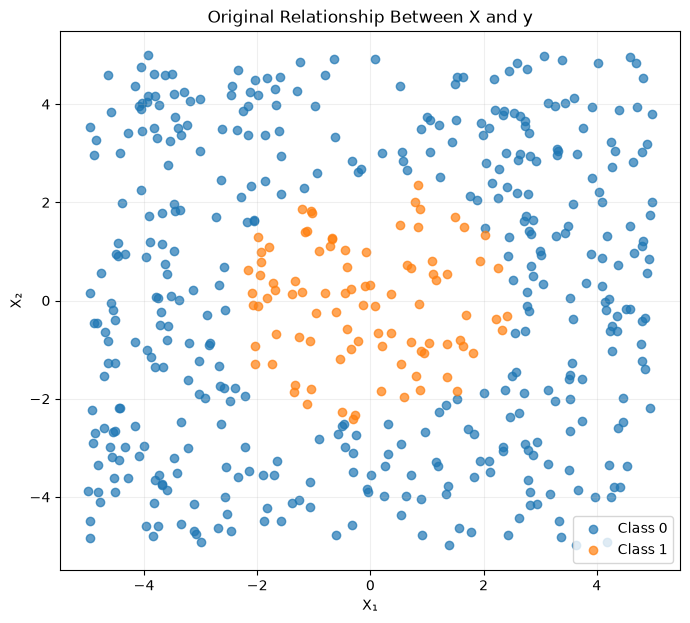

In [39]:
plot_original_relationship(X, y)